# Connecting to the DataBase and Package installation

In [1]:
system('sudo apt-get update && sudo apt-get install -y libgsl-dev')

In [2]:
system('sudo apt-get update && sudo apt-get install -y libssl-dev libsasl2-dev ')

In [3]:
install.packages("mongolite")
install.packages("tidytext")
install.packages("reshape2")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SnowballC’, ‘janeaustenr’, ‘tokenizers’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
#libraries
library(mongolite)
library(tidyverse)
library(tidytext)
library(ggplot2)
library(dplyr)

In [5]:
# Connection Settings
mongo_user <- "teresali"
mongo_password <- "123abc"
mongo_cluster <- "cluster1.ow8c4i0.mongodb.net"
mongo_db <- "Cluster1"

uri <- paste0("mongodb+srv://", mongo_user, ":", mongo_password, "@", mongo_cluster, "/", mongo_db)

In [8]:
collection_name <- "text_summarized"

# Connect and fetch
con <- mongo(collection = collection_name, db = mongo_db, url = uri)
df_summarized <- con$find()

print("Data loaded from MongoDB!")

[1] "Data loaded from MongoDB!"


# Sentiment Score Analysis

### 1. Building Model

In [21]:
# 1. Get the Sentiment Dictionary (Bing lexicon)
# 'bing' is simple: Positive vs Negative
bing_lexicon <- get_sentiments("bing")

# 2. Join cleaned data with the sentiments
# Only keep words that have a sentiment score
df_sentiment <- df_summarized %>%
  inner_join(bing_lexicon, by = c("lemma" = "word")) %>%
  group_by(source_type, sentiment) %>%
  summarize(word_count = sum(count), .groups = 'drop')

# Calculate the percentage of positive vs negative per source
df_sentiment_perc <- df_sentiment %>%
  group_by(source_type) %>%
  mutate(percent = word_count / sum(word_count) * 100)

### 2. Model Plotting

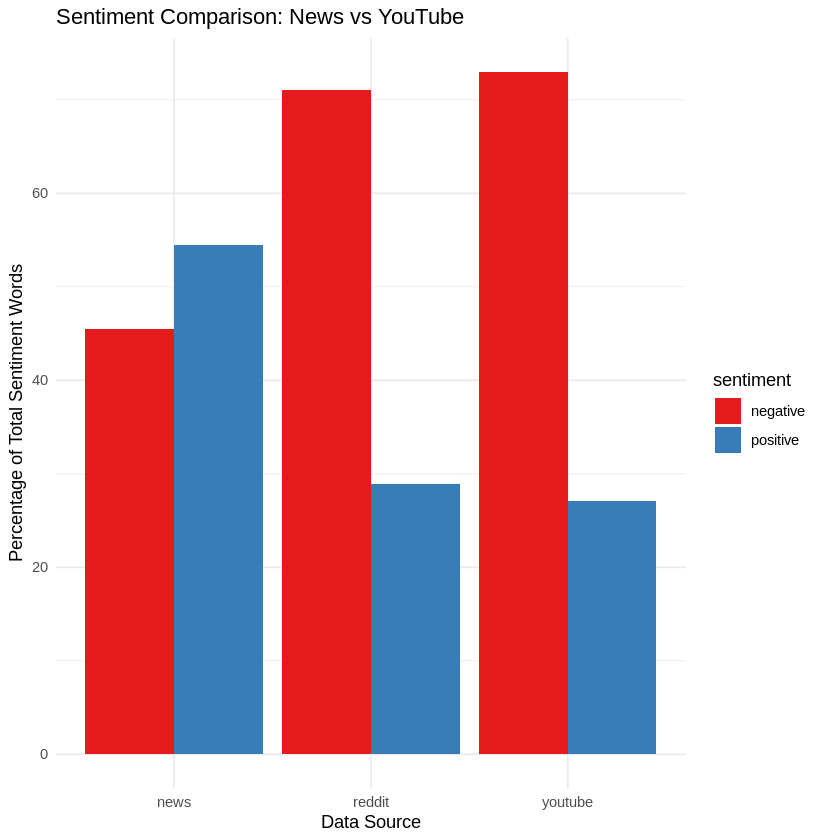

In [22]:
# Generate the Sentiment Bar Chart
ggplot(df_sentiment_perc, aes(x = source_type, y = percent, fill = sentiment)) +
  geom_col(position = "dodge") +
  scale_fill_manual(values = c("negative" = "#e41a1c", "positive" = "#377eb8")) +
  labs(title = "Sentiment Comparison: News vs YouTube",
       x = "Data Source",
       y = "Percentage of Total Sentiment Words") +
  theme_minimal()

### 3. Result Uploading

In [11]:
# Score = (Positive - Negative) / Total
sentiment_table <- df_sentiment_perc %>%
  select(source_type, sentiment, percent) %>%
  pivot_wider(names_from = sentiment, values_from = percent) %>%
  mutate(net_sentiment_score = positive - negative)

# 2. Push to MongoDB
m_sent <- mongo(collection = "Sentiment_Score_Analysis", url = uri)
m_sent$drop()
m_sent$insert(sentiment_table)

print("Part 3: Sentiment Table pushed to MongoDB!")

List of 5
 $ nInserted  : num 3
 $ nMatched   : num 0
 $ nRemoved   : num 0
 $ nUpserted  : num 0
 $ writeErrors: list()

[1] "Part 3: Sentiment Table pushed to MongoDB!"


# Sentiment Frequency Analysis

### 1. Model Building

In [23]:
# 1. Get the Bing lexicon
bing_lexicon <- get_sentiments("bing")

# 2. Join and count the frequency of each word per source
# This keeps the 'count' from your MongoDB data
df_sentiment_freq <- df_summarized %>%
  inner_join(bing_lexicon, by = c("lemma" = "word")) %>%
  group_by(source_type, sentiment, lemma) %>%
  summarize(total_frequency = sum(count), .groups = 'drop') %>%
  arrange(desc(total_frequency))

# 3. PRINT the top 10 most frequent sentiment words overall
print("--- Top 10 Most Frequent Sentiment Words Found ---")
print(head(df_sentiment_freq, 10))

[1] "--- Top 10 Most Frequent Sentiment Words Found ---"
# A tibble: 10 × 4
   source_type sentiment lemma  total_frequency
   <chr>       <chr>     <chr>            <int>
 1 youtube     negative  bad               1768
 2 youtube     negative  hate               787
 3 youtube     positive  safe               636
 4 youtube     negative  stupid             580
 5 youtube     negative  wrong              546
 6 youtube     negative  lose               468
 7 youtube     negative  ruin               397
 8 youtube     negative  suck               376
 9 youtube     negative  fuck               366
10 youtube     negative  refuse             360


### 2. Result Uploading

In [24]:
# 1. Prepare the dataframe for the database

freq_table <- df_sentiment_freq %>%
  rename(word = lemma, n = total_frequency)

# 2. Push to MongoDB
m_freq <- mongo(collection = "Sentiment_Frequency_Analysis", url = uri)
m_freq$drop()
m_freq$insert(freq_table)

print("Part 3: Sentiment Frequency table pushed to MongoDB!")

List of 5
 $ nInserted  : num 446
 $ nMatched   : num 0
 $ nRemoved   : num 0
 $ nUpserted  : num 0
 $ writeErrors: list()

[1] "Part 3: Sentiment Frequency table pushed to MongoDB!"


# Rating Descriptive Analysis (Current)


### 1. Plotting

[1] "Ratings dataset:"
         date avg_rating review_count          phase
1  2025-11-15        4.4     37900000 before rollout
2  2025-11-30        4.4     38000000 before rollout
3  2025-12-17        4.4     38000000 before rollout
4  2025-12-31        4.4     38300000 before rollout
5  2026-01-07        4.3     38400000  after rollout
6  2026-01-15        4.3     38500000  after rollout
7  2026-01-20        4.3     38400000  after rollout
8  2026-01-30        4.2     38800000  after rollout
9  2026-02-06        4.2     38900000  after rollout
10 2026-02-10        4.2     38900000  after rollout
11 2026-02-18        4.2     39000000  after rollout
12 2026-02-26        4.2     39100000  after rollout
13 2026-03-03        4.2     39200000  after rollout
14 2026-03-10        4.2     39200000  after rollout
15 2026-03-17        4.0     39300000  after rollout
16 2026-03-24        4.2     39400000  after rollout
17 2026-03-26        4.0     39400000  after rollout
18 2026-03-29        4.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


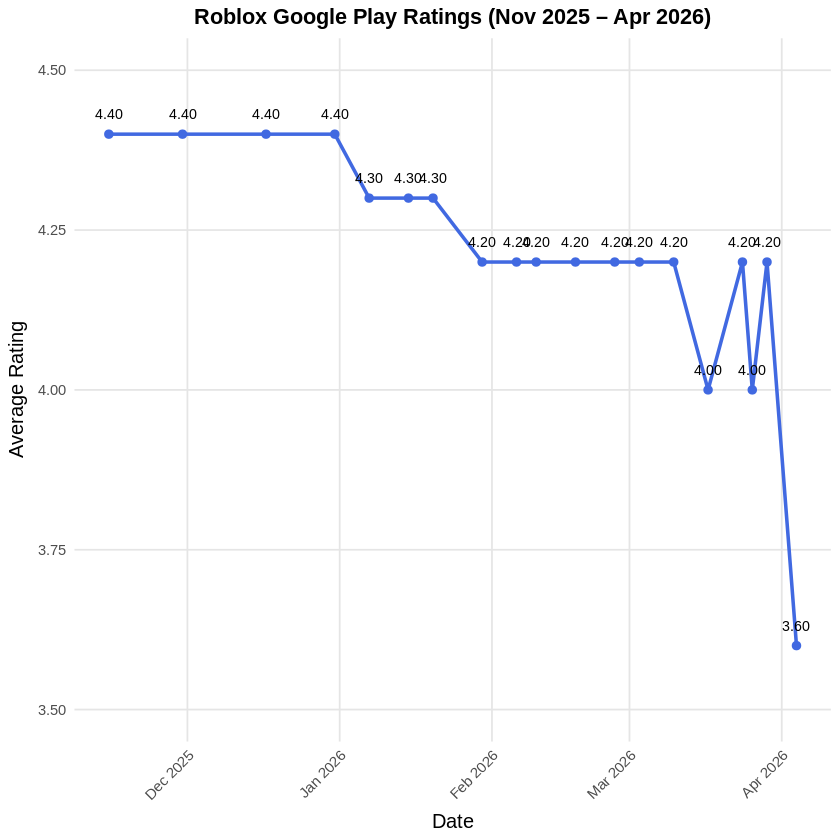

In [15]:
# 1. Query ratings dataset from MongoDB
con <- mongo(collection = "ratings_data", db = mongo_db, url = uri)
ratings_data <- con$find("{}")

# 2. Data Preparation
df_ratings <- ratings_data %>%
  mutate(date = as.Date(date)) %>%
  arrange(date)

# Print dataset (similar to Python's head/print)
print("Ratings dataset:")
print(df_ratings[, c("date", "avg_rating", "review_count", "phase")])

# 3. Plot ratings trend
ggplot(df_ratings, aes(x = date, y = avg_rating)) +
  # Line and points
  geom_line(color = "royalblue", size = 1) +
  geom_point(color = "royalblue", size = 2) +
  # Annotate points with rating values
  geom_text(aes(label = sprintf("%.2f", avg_rating)),
            vjust = -1.5, size = 3) +
  # Scales and Limits
  scale_y_continuous(limits = c(3.5, 4.5)) +
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  # Styling
  theme_minimal() +
  theme(
    plot.title = element_text(size = 13, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank()
  ) +
  labs(
    title = "Roblox Google Play Ratings (Nov 2025 – Apr 2026)",
    x = "Date",
    y = "Average Rating"
  )


### 2. T-Test --> Check if its average changed before and after the policies

In [16]:
# 1. Prepare the two groups for comparison
# 'phase' column identifies 'Pre' and 'Post' update
# We want to see if the Mean (Average) is different
t_result <- t.test(avg_rating ~ phase, data = df_ratings)

# 2. Extract the "Proof"
# the P-Value
p_val <- t_result$p.value
mean_diff <- t_result$estimate[1] - t_result$estimate[2]

# 3. Print the results for your report
print("--- T-test Results ---")
print(t_result)

# Quick interpretation:
if(p_val < 0.05) {
  print("The rating drop is STATISTICALLY SIGNIFICANT (p < 0.05)")
} else {
  print("The change is not significant (it might be random)")
}

[1] "--- T-test Results ---"

	Welch Two Sample t-test

data:  avg_rating by phase
t = -5.4052, df = 14, p-value = 9.273e-05
alternative hypothesis: true difference in means between group after rollout and group before rollout is not equal to 0
95 percent confidence interval:
 -0.3445437 -0.1487896
sample estimates:
 mean in group after rollout mean in group before rollout 
                    4.153333                     4.400000 

[1] "The rating drop is STATISTICALLY SIGNIFICANT (p < 0.05)"


### 3. Result Uploading

In [27]:
# 1. Extract detailed components from the t-test object
p_val <- t_result$p.value
mean_group1 <- t_result$estimate[1] # Mean of Group 1
mean_group2 <- t_result$estimate[2] # Mean of Group 2
conf_low <- t_result$conf.int[1]    # Lower bound of confidence interval
conf_high <- t_result$conf.int[2]   # Upper bound of confidence interval
df_value <- t_result$parameter      # Degrees of freedom

# 2. Create an enhanced summary table
t_test_result_enhanced <- data.frame(
  test_type = "Welch Two Sample t-test",
  group_names = paste(names(t_result$estimate), collapse = " vs "),
  mean_1 = round(mean_group1, 3),
  mean_2 = round(mean_group2, 3),
  avg_diff = round(mean_group1 - mean_group2, 3),
  conf_int_low = round(conf_low, 3),
  conf_int_high = round(conf_high, 3),
  p_value = round(p_val, 4),
  df = round(df_value, 2),
  is_significant = p_val < 0.05
)

# 3. Push to MongoDB (Overwriting the previous simple table)
m_stats <- mongo(collection = "Rating_Significance", url = uri)
m_stats$drop()
m_stats$insert(t_test_result_enhanced)

print("Significance data pushed to MongoDB!")

List of 5
 $ nInserted  : num 1
 $ nMatched   : num 0
 $ nRemoved   : num 0
 $ nUpserted  : num 0
 $ writeErrors: list()

[1] "Significance data pushed to MongoDB!"


# Rating Predictive model

If they have not fixed the age verification in May or June 2026

### 1. Building Model



In [18]:
# Filter data to start from January 1, 2026
df_after <- df_ratings %>%
  filter(date >= as.Date("2026-01-01")) %>%
  mutate(time_index = as.numeric(date - as.Date("2026-01-01")))

# 2. Train the Linear Regression Model
model_lm_after <- lm(avg_rating ~ time_index, data = df_after)

# 3. Summary of the model
# Check the 'Coefficients' to see the daily drop rate
summary(model_lm_after)

print("Predictive Linear Model trained!")


Call:
lm(formula = avg_rating ~ time_index, data = df_after)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.38947 -0.03709 -0.00768  0.06849  0.18583 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.372368   0.077517  56.406  < 2e-16 ***
time_index  -0.004117   0.001295  -3.179  0.00725 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1376 on 13 degrees of freedom
Multiple R-squared:  0.4374,	Adjusted R-squared:  0.3941 
F-statistic: 10.11 on 1 and 13 DF,  p-value: 0.007254


[1] "Predictive Linear Model trained!"


### 2. Model Plotting

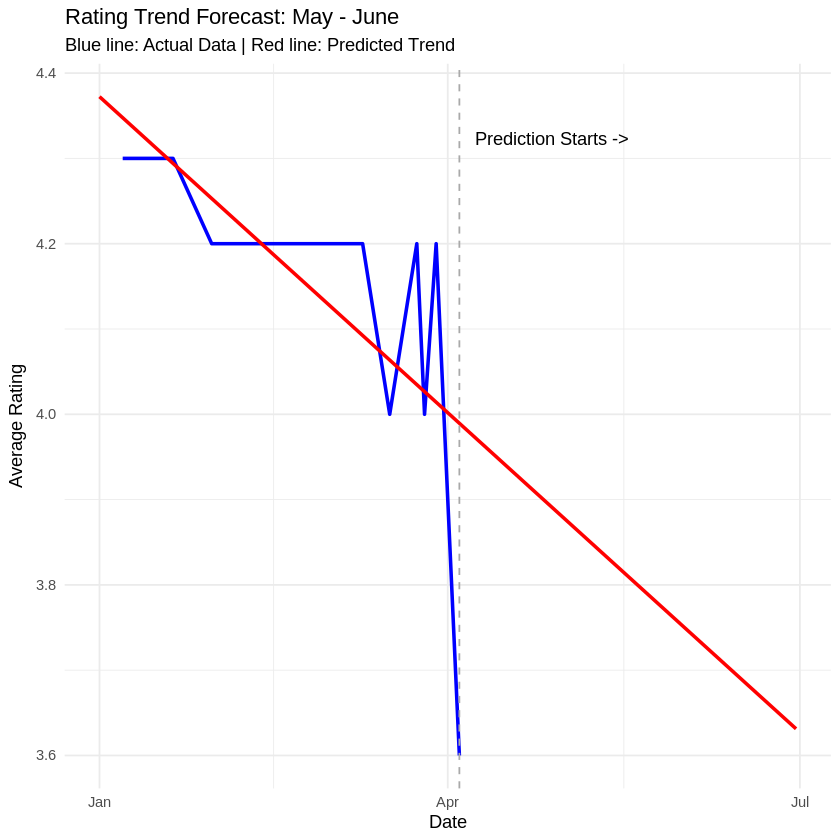

In [19]:
# 1. Create a sequence of dates from the start of Jan through the end of June
future_dates <- seq(as.Date("2026-01-01"), as.Date("2026-06-30"), by = "day")

# 2. Create a data frame for prediction
df_forecast <- data.frame(
  date = future_dates,
  time_index = as.numeric(future_dates - as.Date("2026-01-01"))
)

# 3. Predict the ratings using the trained model
df_forecast$pred_rating <- predict(model_lm_after, newdata = df_forecast)

# 4. Plotting the results
ggplot() +
  # blue geom_line for historical data
  geom_line(data = df_after, aes(x = date, y = avg_rating), color = "blue", size = 1) +

  # Plot the regression line (The "Red Line" forecast)
  geom_line(data = df_forecast, aes(x = date, y = pred_rating), color = "red", size = 1, linetype = "solid") +

  geom_vline(xintercept = max(df_after$date), linetype = "dashed", color = "darkgrey") +

  annotate("text", x = max(df_after$date), y = max(df_after$avg_rating),
           label = "Prediction Starts ->", vjust = -1, hjust = -0.1, color = "black") +

  labs(
    title = "Rating Trend Forecast: May - June",
    subtitle = "Blue line: Actual Data | Red line: Predicted Trend",
    x = "Date",
    y = "Average Rating"
  ) +
  theme_minimal()

### 3. Result Uploading

In [20]:
model_stats_after <- data.frame(
  intercept = as.numeric(coef(model_lm_after)[1]),
  slope = as.numeric(coef(model_lm_after)[2]),
  r_squared = summary(model_lm_after)$r.squared,
  model_start_date = as.Date("2026-01-01"),
  target_variable = "avg_rating_post_rollout",
  last_updated = Sys.time()
)

# 2. Push to MongoDB
m_pred <- mongo(collection = "Model_Predictions", url = uri)
m_pred$drop()
m_pred$insert(model_stats_after)

print("Prediction parameters pushed to MongoDB!")

List of 5
 $ nInserted  : num 1
 $ nMatched   : num 0
 $ nRemoved   : num 0
 $ nUpserted  : num 0
 $ writeErrors: list()

[1] "Prediction parameters pushed to MongoDB!"


The Slope ($\beta_1$): If the slope is negative (e.g., -0.01), you can tell : "For every day that passes without fixing the Age Verification bug, the rating is predicted to drop by 0.01 stars.

The R-Squared: This tells you how "accurate" your prediction is. An R-squared of 0.80 means your model explains 80% of the rating changes.

The Forecast: It gives the stakeholders a "Warning" of what will happen if they don't take action.